In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

In [9]:
x, y = make_classification(n_samples=1000, n_features=2, n_classes=2, n_clusters_per_class=1, n_redundant=0)

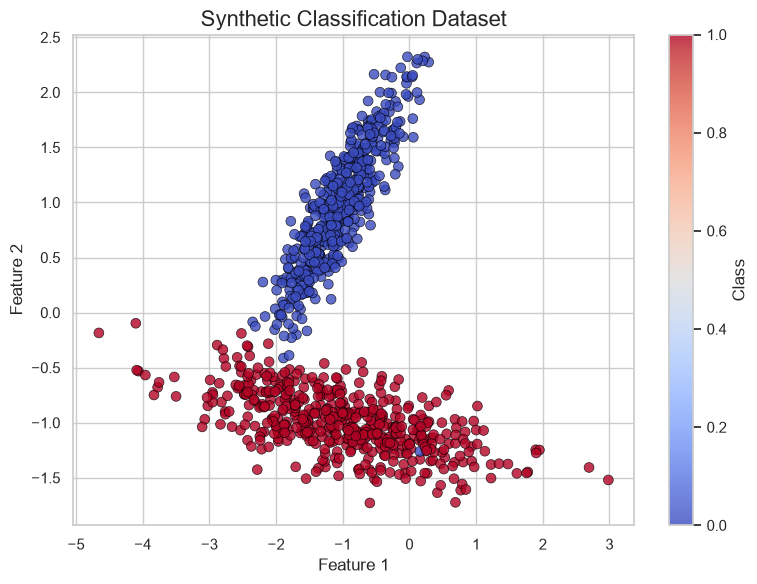

In [10]:
# Apply a clean theme
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 6))

plt.scatter(
    x[:, 0],
    x[:, 1],
    c=y,
    cmap="coolwarm",
    s=50,          # Point size
    alpha=0.8,     # Transparency
    edgecolors="black",
    linewidth=0.5
)

plt.title("Synthetic Classification Dataset", fontsize=16)
plt.xlabel("Feature 1", fontsize=12)
plt.ylabel("Feature 2", fontsize=12)
plt.colorbar(label="Class")
plt.tight_layout()

plt.show()

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

X_train, X_test, y_train, y_test = train_test_split(x, y, random_state=42)

In [12]:
from sklearn.naive_bayes import GaussianNB
svc = GaussianNB(kernel="linear")
svc.fit(X_train, y_train)
y_pred = svc.predict(X_test)
true_pred = (y_pred==y_test).sum()
false_pred = (y_pred!=y_test).sum()

print("Correct Predictions :", true_pred)
print("Incorrect Predictions:", false_pred)

# Evaluation scores
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

# Detailed Report
print("\nClassification Report")
print(classification_report(y_test, y_pred))

Correct Predictions : 248
Incorrect Predictions: 2
Accuracy : 0.992
Precision: 0.9919354838709677
Recall   : 0.9919354838709677
F1 Score : 0.9919354838709677

Confusion Matrix
[[125   1]
 [  1 123]]

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       126
           1       0.99      0.99      0.99       124

    accuracy                           0.99       250
   macro avg       0.99      0.99      0.99       250
weighted avg       0.99      0.99      0.99       250



In [6]:
def isdinner(s):
    if "Dinner" in s:
        return 1
    return 0
def islunch(s):
    if "Lunch" in s:
        return 1
    return 0
df["is_dinner"] = df["time"].apply(isdinner)
df["is_lunch"] = df["time"].apply(islunch)

In [7]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)
encoded = encoder.fit_transform(df[["day"]])
encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(["day"])
)

# Add the encoded columns to the original DataFrame
df = pd.concat([df, encoded_df], axis=1)
df = df.drop("day", axis=1)